In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from helpers.select_scenario import select_scenario
from helpers.load import *

In [15]:
scenario_folder = select_scenario()

Select a scenario:
[0]: lake
[1]: soil
Selected scenario: lake

Select a test run:
[0]: 2025-03-01_07:30
[1]: 2025-03-01_07:31
[2]: 2025-03-01_07:32
Selected run: 2025-03-01_07:30


In [16]:
node_pos_df = load_node_pos_df(scenario_folder)
tx_begin_df = load_phy_tx_begin(scenario_folder)
tx_end_df = load_phy_tx_end(scenario_folder)
tx_drop_df = load_phy_tx_drop(scenario_folder)
rx_begin_df = load_phy_rx_begin(scenario_folder)
rx_end_df = load_phy_rx_end(scenario_folder)
rx_drop_df = load_phy_rx_drop(scenario_folder)

In [17]:
def calculate_distances(node_pos_df, packet_df, src_col='SourceNodeId', dst_col='DestinationNodeId'):
    """Calculate distances between source and destination nodes for each packet."""
    distances = []
    
    for _, packet in packet_df.iterrows():
        try:
            # Get positions of source and destination nodes at packet time
            time = packet['Time']
            src_id = packet[src_col]
            dst_id = packet[dst_col]
            
            # Get closest position readings for both nodes
            src_nodes = node_pos_df[node_pos_df['NodeId'] == src_id]
            dst_nodes = node_pos_df[node_pos_df['NodeId'] == dst_id]
            
            if src_nodes.empty or dst_nodes.empty:
                continue
                
            src_pos = src_nodes.iloc[(src_nodes['Time'] - time).abs().argmin()]
            dst_pos = dst_nodes.iloc[(dst_nodes['Time'] - time).abs().argmin()]
            
            # Calculate Euclidean distance
            distance = np.sqrt(
                (float(src_pos['X']) - float(dst_pos['X']))**2 +
                (float(src_pos['Y']) - float(dst_pos['Y']))**2 +
                (float(src_pos['Z']) - float(dst_pos['Z']))**2
            )
            distances.append(distance)
            
        except (KeyError, IndexError):
            continue
    
    return distances

In [18]:
# Calculate distances for all events
tx_begin_distances = calculate_distances(node_pos_df, tx_begin_df)
tx_end_distances = calculate_distances(node_pos_df, tx_end_df)
tx_drop_distances = calculate_distances(node_pos_df, tx_drop_df)
rx_begin_distances = calculate_distances(node_pos_df, rx_begin_df)
rx_end_distances = calculate_distances(node_pos_df, rx_end_df)
rx_drop_distances = calculate_distances(node_pos_df, rx_drop_df)

min_distance = float('inf')
max_distance = 0
for distances in [tx_begin_distances, tx_end_distances, tx_drop_distances, 
                  rx_begin_distances, rx_end_distances, rx_drop_distances]:
    if not distances:
        continue
    min_distance = min(min_distance, min(distances))
    max_distance = max(max_distance, max(distances))

# Create bins for histogram
bins = 50
bin_range = (min_distance, max_distance)

# Create the plot
plt.figure(figsize=(12, 6))

# Plot TX events
tx_hist_begin, _ = np.histogram(tx_begin_distances, bins=bins, range=bin_range)
tx_hist_end, _ = np.histogram(tx_end_distances, bins=bins, range=bin_range)
tx_hist_drop, _ = np.histogram(tx_drop_distances, bins=bins, range=bin_range)

# Plot RX events
rx_hist_begin, edges = np.histogram(rx_begin_distances, bins=bins, range=bin_range)
rx_hist_end, _ = np.histogram(rx_end_distances, bins=bins, range=bin_range)
rx_hist_drop, _ = np.histogram(rx_drop_distances, bins=bins, range=bin_range)

# Calculate bar positions
bar_width = 0.35
x = np.arange(len(edges)-1)

<Figure size 1200x600 with 0 Axes>

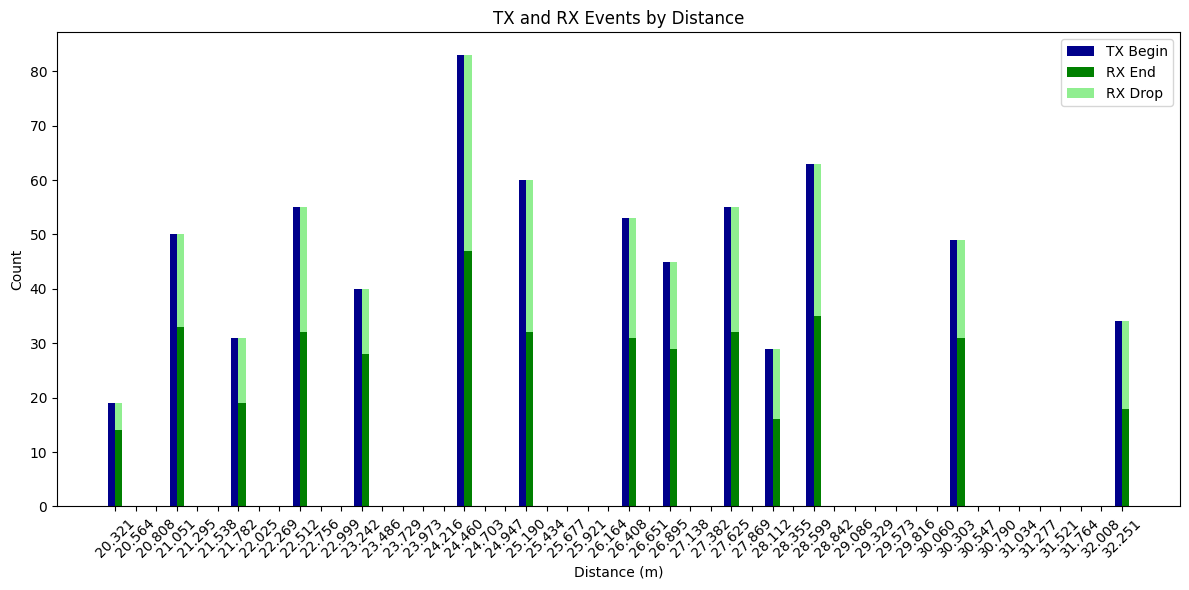

In [19]:
plt.figure(figsize=(12, 6))

plt.bar(x - bar_width/2, tx_hist_begin, bar_width, label='TX Begin', color='darkblue')
#plt.bar(x - bar_width/2, tx_hist_end, bar_width, bottom=tx_hist_begin, label='TX End', color='blue')
#plt.bar(x - bar_width/2, tx_hist_drop, bar_width, bottom=tx_hist_begin+tx_hist_end, label='TX Drop', color='lightblue')

#plt.bar(x + bar_width/2, rx_hist_begin, bar_width, label='RX Begin', color='darkgreen')
#plt.bar(x + bar_width/2, rx_hist_end, bar_width, bottom=rx_hist_begin, label='RX End', color='green')
#plt.bar(x + bar_width/2, rx_hist_drop, bar_width, bottom=rx_hist_begin+rx_hist_end, label='RX Drop', color='lightgreen')
plt.bar(x + bar_width/2, rx_hist_end, bar_width, label='RX End', color='green')
plt.bar(x + bar_width/2, rx_hist_drop, bar_width, bottom=rx_hist_end, label='RX Drop', color='lightgreen')


plt.xticks(x, [f'{(edges[i] + edges[i+1])/2:.3f}' for i in range(len(edges)-1)], rotation=45)
plt.xlabel('Distance (m)')
plt.ylabel('Count')
plt.title('TX and RX Events by Distance')
plt.legend()
plt.tight_layout()
plt.show()